# Image Captioning - Evaluation and Visualization

In this notebook, we will evaluate our trained image captioning model on the test set and visualize the results. We will:

1. Load the trained model and vocabulary
2. Generate captions for test images
3. Compute evaluation metrics (BLEU-1 to BLEU-4)
4. Analyze model performance across different image categories
5. Visualize attention weights (if implemented)
6. Create an interactive demo for inference

In [23]:
import os
import sys
import json
import pickle
import torch
import numpy as np
import pandas as pd
from collections import Counter
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# Add project root to path
sys.path.append('..')

# Import project modules
from models.caption_model import CaptionModel
from utils.vocabulary import Vocabulary
from utils.dataset import get_data_loaders
from utils.metrics import calculate_metrics

## 1. Load Model and Configuration

In [2]:
# Define paths
model_dir = '../models'
config_path = os.path.join(model_dir, 'config.json')
model_path = os.path.join(model_dir, 'best_model_loss.pth')  # or 'best_model_bleu.pth'
vocab_path = os.path.join(model_dir, 'vocabulary.pkl')
data_dir = '../data/flickr8k'

# Load configuration
with open(config_path, 'r') as f:
    config = json.load(f)

# Print configuration
print("Model configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Model configuration:
  data_dir: ../data/flickr8k
  batch_size: 32
  num_workers: 4
  encoder_model: resnet18
  embed_size: 256
  hidden_size: 512
  num_layers: 1
  dropout: 0.5
  decoder_type: lstm
  learning_rate: 0.0003
  num_epochs: 15
  early_stopping_patience: 5
  save_dir: ../models
  device: cuda
  vocab_size: 2986


In [3]:
# Load vocabulary
with open(vocab_path, 'rb') as f:
    vocab = pickle.load(f)

print(f"Loaded vocabulary with {len(vocab)} words")

Loaded vocabulary with 2986 words


In [5]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = CaptionModel(
    embed_size=int(config['embed_size']),
    hidden_size=int(config['hidden_size']),
    vocab_size=len(vocab),
    num_layers=int(config['num_layers']),
    encoder_model=config['encoder_model'],
    decoder_type=config['decoder_type'],
    dropout=float(config['dropout'])
)

# Load model weights
checkpoint = torch.load(model_path,
                        map_location=device,
                        weights_only=False
                       )
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"Model loaded from {model_path}")

Using device: cuda
Model loaded from ../models/best_model_loss.pth


## 2. Load Test Data

In [6]:
# Get data loaders
_, _, test_loader, _ = get_data_loaders(
    data_dir=data_dir,
    batch_size=1,  # Process one image at a time for evaluation
    num_workers=4
)

print(f"Loaded test set with {len(test_loader)} images")

Loaded test set with 5000 images


## 3. Generate Captions for Test Images

In [7]:
# Generate captions for all test images
def generate_test_captions(model, test_loader, vocab, device, beam_size=1):
    """Generate captions for all test images."""
    results = []
    model.eval()

    with torch.no_grad():
        for images, captions, image_ids in tqdm(test_loader, desc="Generating captions"):
            images = images.to(device)

            predicted_ids = model.generate_caption(images, beam_size=beam_size)
            predicted_caption = vocab.decode(predicted_ids, join=True, remove_special=True)
            ground_truth_caption = vocab.decode(captions[0], join=True, remove_special=True)

            results.append({
                'image_id': image_ids[0],
                'ground_truth': ground_truth_caption,
                'predicted': predicted_caption
            })

    return pd.DataFrame(results)

# Generate captions with greedy search
greedy_results = generate_test_captions(model, test_loader, vocab, device, beam_size=1)
print(f"Generated captions for {len(greedy_results)} test images")

# Show a few examples
greedy_results.head()

Generating captions: 100%|█████████████████████████████████████████████████████████| 5000/5000 [00:57<00:00, 86.56it/s]

Generated captions for 5000 test images


,image_id,ground_truth,predicted
0,1056338697_4f7d7ce270.jpg,blond woman in blue shirt appears to wait for ...,woman in blue shirt and jeans is standing in f...
1,1056338697_4f7d7ce270.jpg,blond woman is on the street <UNK> <UNK>,woman in blue shirt and jeans is standing in f...
2,1056338697_4f7d7ce270.jpg,woman is <UNK> is to traffic as seen from behind,woman in blue shirt and jeans is standing in f...
3,1056338697_4f7d7ce270.jpg,woman with blonde hair wearing blue tube top i...,woman in blue shirt and jeans is standing in f...
4,1056338697_4f7d7ce270.jpg,the woman in the blue dress is holding out her...,woman in blue shirt and jeans is standing in f...


In [8]:
# Generate captions with beam search (this might take longer)
beam_results = generate_test_captions(model, test_loader, vocab, device, beam_size=3)
print(f"Generated captions with beam search for {len(beam_results)} test images")

# Compare to greedy search
comparison_df = pd.DataFrame({
    'image_id': greedy_results['image_id'],
    'ground_truth': greedy_results['ground_truth'],
    'greedy_search': greedy_results['predicted'],
    'beam_search': beam_results['predicted']
})

# Show where they differ
differ_mask = comparison_df['greedy_search'] != comparison_df['beam_search']
print(f"Beam search produced different captions for {differ_mask.sum()} images ({differ_mask.sum() / len(comparison_df) * 100:.1f}%)")

# Show a few examples where they differ
comparison_df[differ_mask].head()

Generating captions: 100%|█████████████████████████████████████████████████████████| 5000/5000 [02:02<00:00, 40.74it/s]

Generated captions with beam search for 5000 test images
Beam search produced different captions for 4055 images (81.1%)


,image_id,ground_truth,greedy_search,beam_search
0,1056338697_4f7d7ce270.jpg,blond woman in blue shirt appears to wait for ...,woman in blue shirt and jeans is standing in f...,the man in the blue shirt is standing in front...
1,1056338697_4f7d7ce270.jpg,blond woman is on the street <UNK> <UNK>,woman in blue shirt and jeans is standing in f...,the man in the blue shirt is standing in front...
2,1056338697_4f7d7ce270.jpg,woman is <UNK> is to traffic as seen from behind,woman in blue shirt and jeans is standing in f...,the man in the blue shirt is standing in front...
3,1056338697_4f7d7ce270.jpg,woman with blonde hair wearing blue tube top i...,woman in blue shirt and jeans is standing in f...,the man in the blue shirt is standing in front...
4,1056338697_4f7d7ce270.jpg,the woman in the blue dress is holding out her...,woman in blue shirt and jeans is standing in f...,the man in the blue shirt is standing in front...


## 4. Calculate Evaluation Metrics

In [9]:
# Calculate BLEU scores
def calculate_bleu_scores(results_df):
    """Calculate BLEU-1 to BLEU-4 scores for generated captions."""
    references = []
    hypotheses = []

    for _, row in results_df.iterrows():
        references.append([nltk.word_tokenize(row['ground_truth'])])
        hypotheses.append(nltk.word_tokenize(row['predicted']))

    smoothing = SmoothingFunction().method1

    bleu_scores = []
    for n in range(1, 5):
        weights = tuple(1.0 / n for _ in range(n))
        score = corpus_bleu(references, hypotheses, weights=weights, smoothing_function=smoothing)
        bleu_scores.append(score)

    return bleu_scores

# Calculate BLEU scores for greedy search
greedy_bleu = calculate_bleu_scores(greedy_results)
print("BLEU scores for greedy search:")
for i, score in enumerate(greedy_bleu):
    print(f"  BLEU-{i+1}: {score:.4f}")

# Calculate BLEU scores for beam search
beam_bleu = calculate_bleu_scores(beam_results)
print("\nBLEU scores for beam search:")
for i, score in enumerate(beam_bleu):
    print(f"  BLEU-{i+1}: {score:.4f}")

BLEU scores for greedy search:
  BLEU-1: 0.1982
  BLEU-2: 0.1014
  BLEU-3: 0.0558
  BLEU-4: 0.0305

BLEU scores for beam search:
  BLEU-1: 0.1814
  BLEU-2: 0.0967
  BLEU-3: 0.0553
  BLEU-4: 0.0311


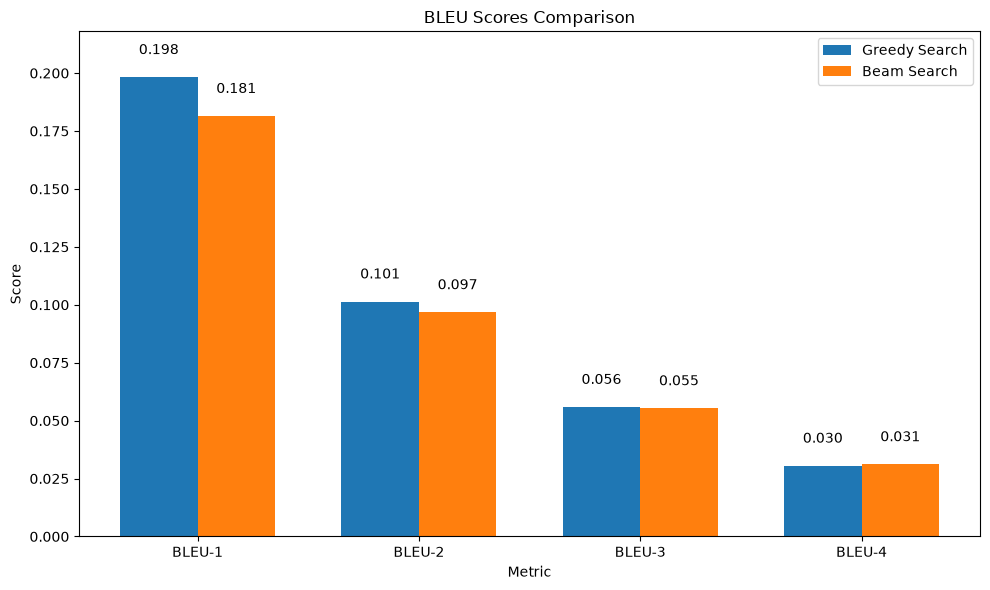

In [10]:
# Compare BLEU scores
bleu_comparison = pd.DataFrame({
    'Metric': ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4'],
    'Greedy Search': greedy_bleu,
    'Beam Search': beam_bleu
})

# Plot comparison
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(bleu_comparison['Metric']))

plt.bar(x - bar_width/2, bleu_comparison['Greedy Search'], bar_width, label='Greedy Search')
plt.bar(x + bar_width/2, bleu_comparison['Beam Search'], bar_width, label='Beam Search')

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('BLEU Scores Comparison')
plt.xticks(x, bleu_comparison['Metric'])
plt.legend()
plt.ylim(0, max(max(greedy_bleu), max(beam_bleu)) * 1.1)  # Add some margin at the top

# Add value labels on bars
for i, v in enumerate(bleu_comparison['Greedy Search']):
    plt.text(i - bar_width/2, v + 0.01, f'{v:.3f}', ha='center')
    
for i, v in enumerate(bleu_comparison['Beam Search']):
    plt.text(i + bar_width/2, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 5. Analyze Results by Caption Length

In [11]:
# Add caption lengths to the results dataframe
greedy_results['gt_length'] = greedy_results['ground_truth'].apply(lambda x: len(nltk.word_tokenize(x)))
greedy_results['pred_length'] = greedy_results['predicted'].apply(lambda x: len(nltk.word_tokenize(x)))

# Calculate average lengths
avg_gt_length = greedy_results['gt_length'].mean()
avg_pred_length = greedy_results['pred_length'].mean()

print(f"Average ground truth caption length: {avg_gt_length:.2f} words")
print(f"Average predicted caption length: {avg_pred_length:.2f} words")

Average ground truth caption length: 9.72 words
Average predicted caption length: 8.59 words


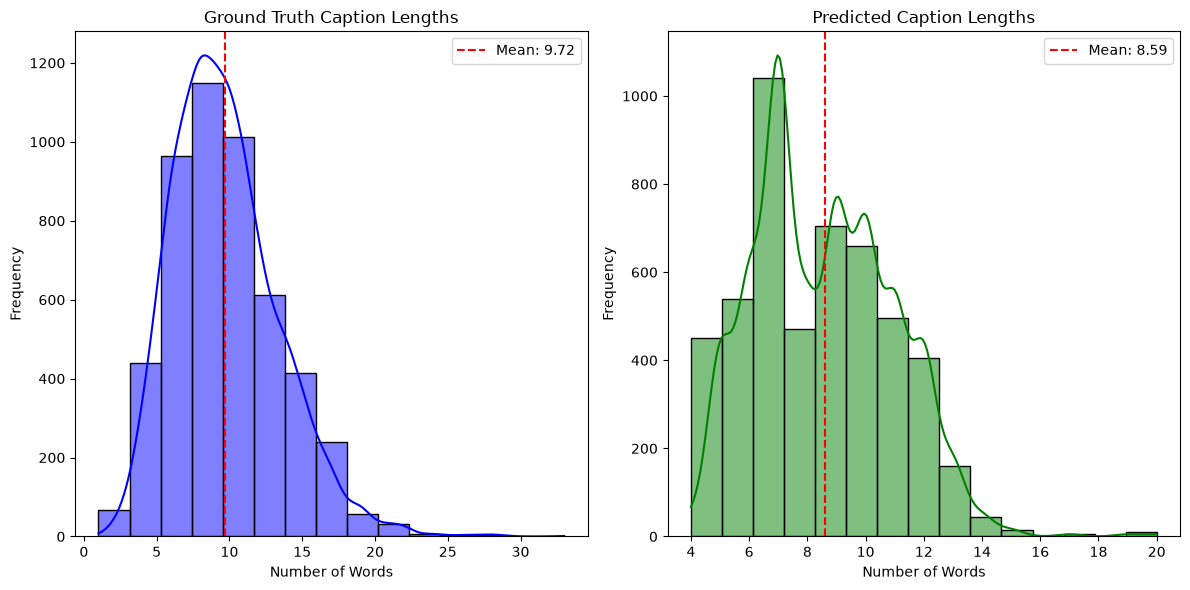

In [12]:
# Plot caption length distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(greedy_results['gt_length'], kde=True, bins=15, color='blue')
plt.axvline(avg_gt_length, color='red', linestyle='--', label=f'Mean: {avg_gt_length:.2f}')
plt.title('Ground Truth Caption Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(greedy_results['pred_length'], kde=True, bins=15, color='green')
plt.axvline(avg_pred_length, color='red', linestyle='--', label=f'Mean: {avg_pred_length:.2f}')
plt.title('Predicted Caption Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
# Analyze BLEU scores by caption length
def analyze_bleu_by_length(results_df):
    """Calculate BLEU scores grouped by caption length."""
    bins = [0, 5, 10, 15, 20, float('inf')]
    labels = ['0-5', '5-10', '10-15', '15-20', '20+']

    df = results_df.copy()
    df['length_bin'] = pd.cut(df['gt_length'], bins=bins, labels=labels, right=False)

    smoothing = SmoothingFunction().method1
    rows = []

    for label in labels:
        subset = df[df['length_bin'] == label]
        count = len(subset)

        row = {'Length Bin': label, 'Count': count}
        if count == 0:
            row.update({f'BLEU-{n}': 0.0 for n in range(1, 5)})
        else:
            references = [[nltk.word_tokenize(gt)] for gt in subset['ground_truth']]
            hypotheses = [nltk.word_tokenize(pred) for pred in subset['predicted']]
            for n in range(1, 5):
                weights = tuple(1.0 / n for _ in range(n))
                row[f'BLEU-{n}'] = corpus_bleu(references, hypotheses, weights=weights, smoothing_function=smoothing)

        rows.append(row)

    bleu_df = pd.DataFrame(rows).set_index('Length Bin')
    return bleu_df

# Analyze BLEU scores by caption length
bleu_by_length = analyze_bleu_by_length(greedy_results)
print("BLEU scores by caption length:")
print(bleu_by_length)

BLEU scores by caption length:
            Count    BLEU-1    BLEU-2    BLEU-3    BLEU-4
Length Bin                                               
0-5           219  0.102762  0.037696  0.010118  0.003079
5-10         2401  0.197447  0.099786  0.053203  0.028120
10-15        1860  0.184667  0.096510  0.054810  0.030846
15-20         457  0.132746  0.068595  0.038596  0.021327
20+            63  0.071173  0.033173  0.017880  0.007670


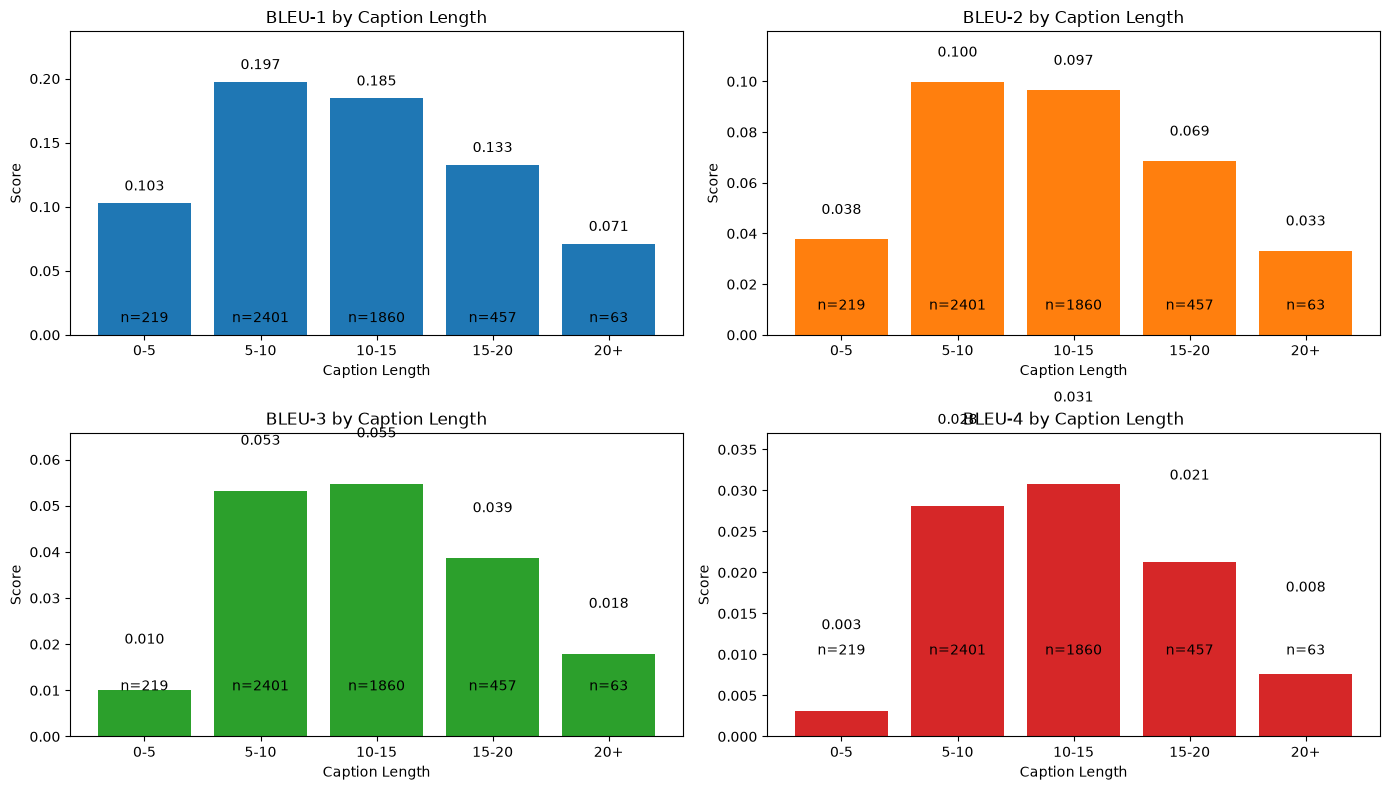

In [15]:
# Plot BLEU scores by caption length
plt.figure(figsize=(14, 8))

# Plot BLEU-1 to BLEU-4
for i in range(4):
    plt.subplot(2, 2, i+1)
    metric = f'BLEU-{i+1}'
    plt.bar(bleu_by_length.index, bleu_by_length[metric], color=f'C{i}')
    plt.xlabel('Caption Length')
    plt.ylabel('Score')
    plt.title(f'{metric} by Caption Length')
    plt.ylim(0, max(bleu_by_length[metric]) * 1.2)  # Add some margin
    
    # Add count as text below the bars
    for j, (idx, count) in enumerate(zip(bleu_by_length.index, bleu_by_length['Count'])):
        plt.text(j, 0.01, f'n={count}', ha='center')
        value = bleu_by_length[metric].iloc[j]
        plt.text(j, value + 0.01, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 6. Visualize Best and Worst Captions

In [16]:
# Calculate per-image BLEU score
def calculate_image_bleu(ground_truth, predicted):
    """Calculate BLEU score for a single image."""
    reference = [nltk.word_tokenize(ground_truth)]
    hypothesis = nltk.word_tokenize(predicted)

    smoothing = SmoothingFunction().method1
    bleu = sentence_bleu(reference, hypothesis, smoothing_function=smoothing)

    return bleu

# Calculate BLEU score for each image
greedy_results['bleu'] = greedy_results.apply(
    lambda row: calculate_image_bleu(row['ground_truth'], row['predicted']),
    axis=1
)

# Sort by BLEU score
sorted_results = greedy_results.sort_values('bleu')

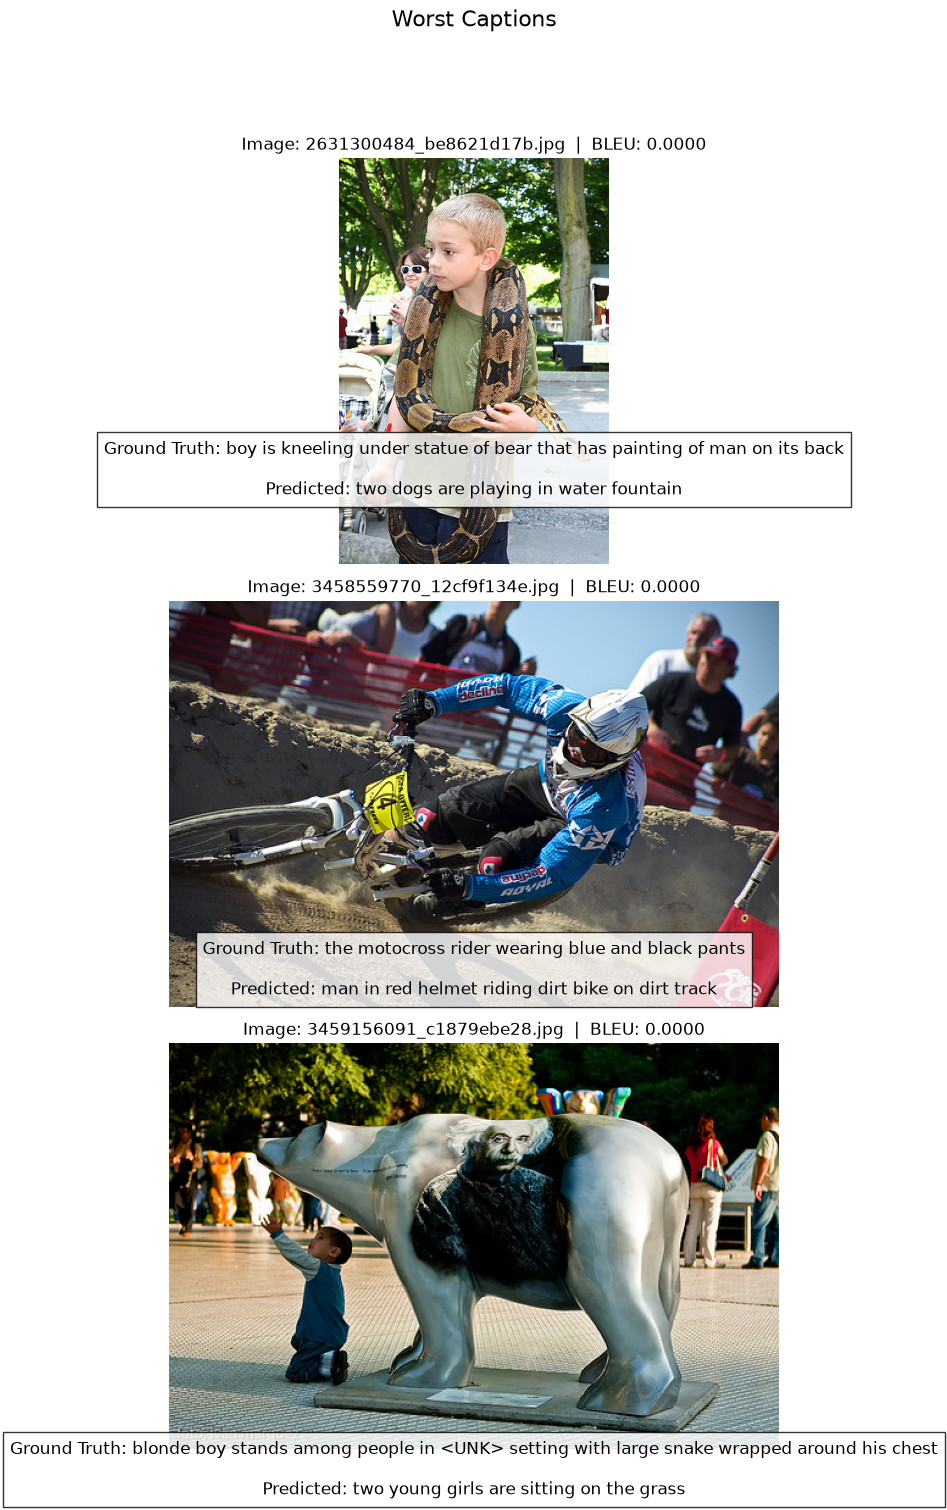

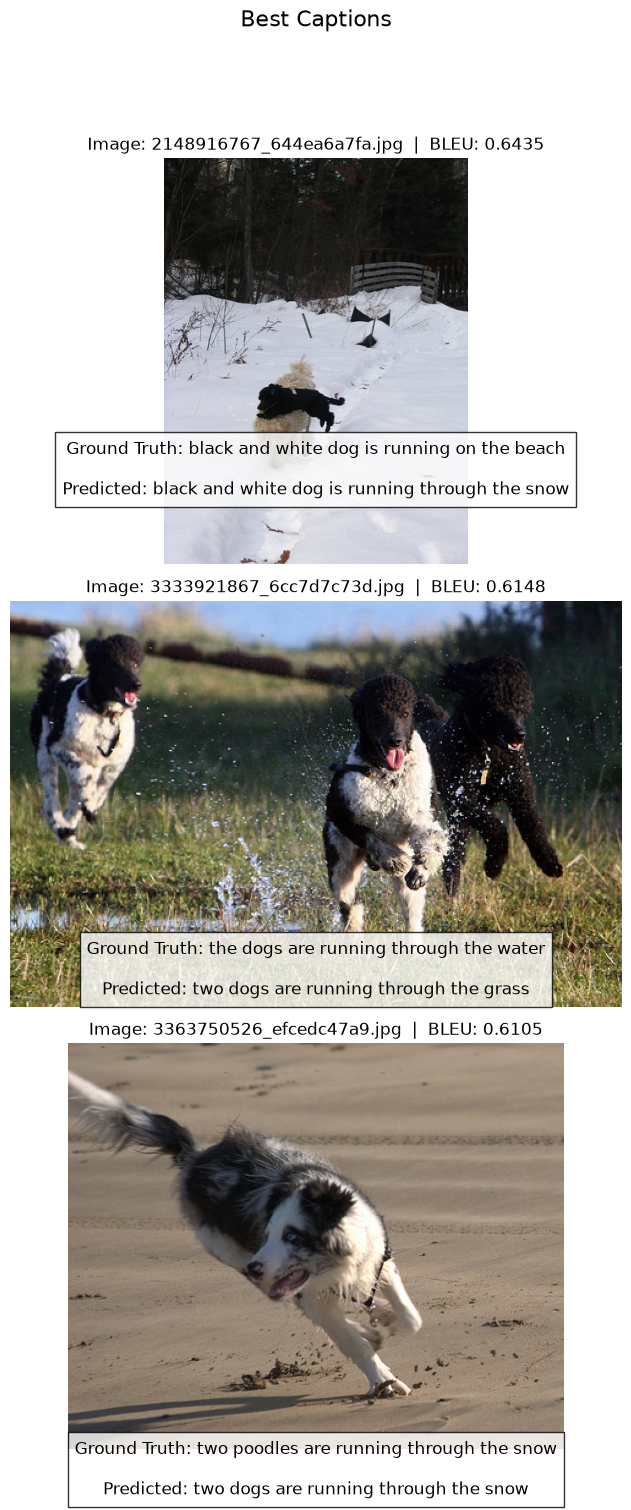

In [17]:
# Display worst and best captions
def display_examples(results_df, image_dir, num_examples=3, best=True):
    """Display examples of captions."""
    if best:
        examples = results_df.tail(num_examples).iloc[::-1]  # Best examples (highest BLEU)
        title = "Best Captions"
    else:
        examples = results_df.head(num_examples)  # Worst examples (lowest BLEU)
        title = "Worst Captions"
    
    # Create figure
    plt.figure(figsize=(15, 5 * num_examples))
    plt.suptitle(title, fontsize=16, y=1.0)
    
    # Display examples
    for i, (_, example) in enumerate(examples.iterrows()):
        # Load and display image
        img_path = os.path.join(image_dir, 'processed', 'images', example['image_id'])
        img = Image.open(img_path)
        
        plt.subplot(num_examples, 1, i+1)
        plt.imshow(img)
        plt.title(f"Image: {example['image_id']}  |  BLEU: {example['bleu']:.4f}")
        plt.axis('off')
        
        # Add captions as text
        caption_text = f"Ground Truth: {example['ground_truth']}\n\n"
        caption_text += f"Predicted: {example['predicted']}"
        
        plt.figtext(0.5, 0.01 + i * (1/num_examples), caption_text, 
                   ha='center', fontsize=12, bbox={"facecolor":"white", "alpha":0.8, "pad":5})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Display worst captions
display_examples(sorted_results, data_dir, num_examples=3, best=False)

# Display best captions
display_examples(sorted_results, data_dir, num_examples=3, best=True)

## 7. Analyze Common Words and Patterns

In [20]:
# Analyze common words in predicted captions
def analyze_word_frequency(texts):
    """Analyze word frequency in a list of texts."""
    counter = Counter()
    for text in texts:
        counter.update(nltk.word_tokenize(text))

    word_df = pd.DataFrame(counter.items(), columns=['word', 'count'])
    word_df = word_df.sort_values('count', ascending=False).reset_index(drop=True)

    return word_df

# Analyze ground truth and predicted captions
gt_words = analyze_word_frequency(greedy_results['ground_truth'])
pred_words = analyze_word_frequency(greedy_results['predicted'])

# Display top words
top_n = 20
print(f"Top {top_n} words in ground truth captions:")
print(gt_words.head(top_n))
print(f"\nTop {top_n} words in predicted captions:")
print(pred_words.head(top_n))

Top 20 words in ground truth captions:
       word  count
0       the   2383
1        in   2316
2        on   1385
3        is   1183
4         >   1156
5       UNK   1156
6         <   1156
7       and   1041
8      with    973
9       dog    952
10      man    933
11       of    810
12      two    696
13    white    523
14      boy    507
15    black    476
16      are    456
17     girl    427
18    woman    388
19  wearing    388

Top 20 words in predicted captions:
        word  count
0         in   3420
1         is   2900
2        the   2430
3        man   1775
4      shirt   1655
5        are   1610
6         of   1555
7         on   1490
8   standing   1390
9        two   1300
10      blue   1200
11       and   1110
12   through    945
13   running    870
14     grass    830
15   playing    820
16     front    785
17       dog    655
18     jeans    615
19      with    570


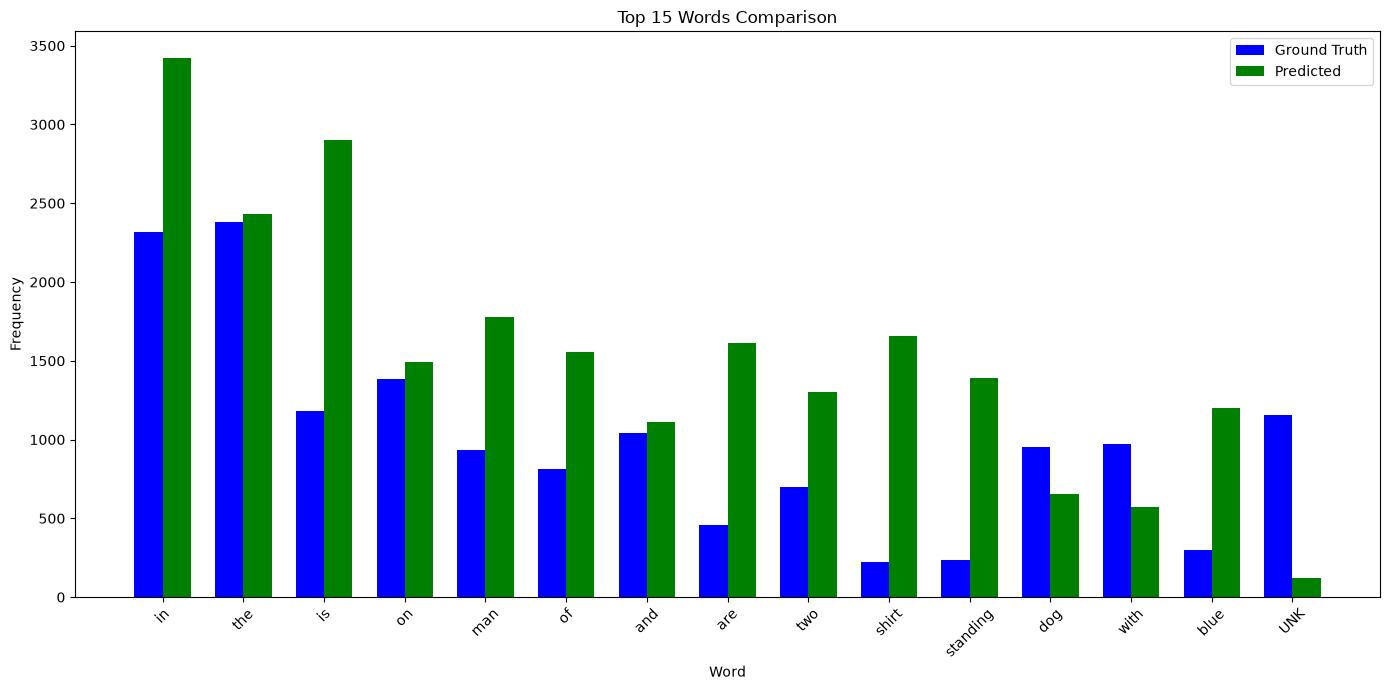

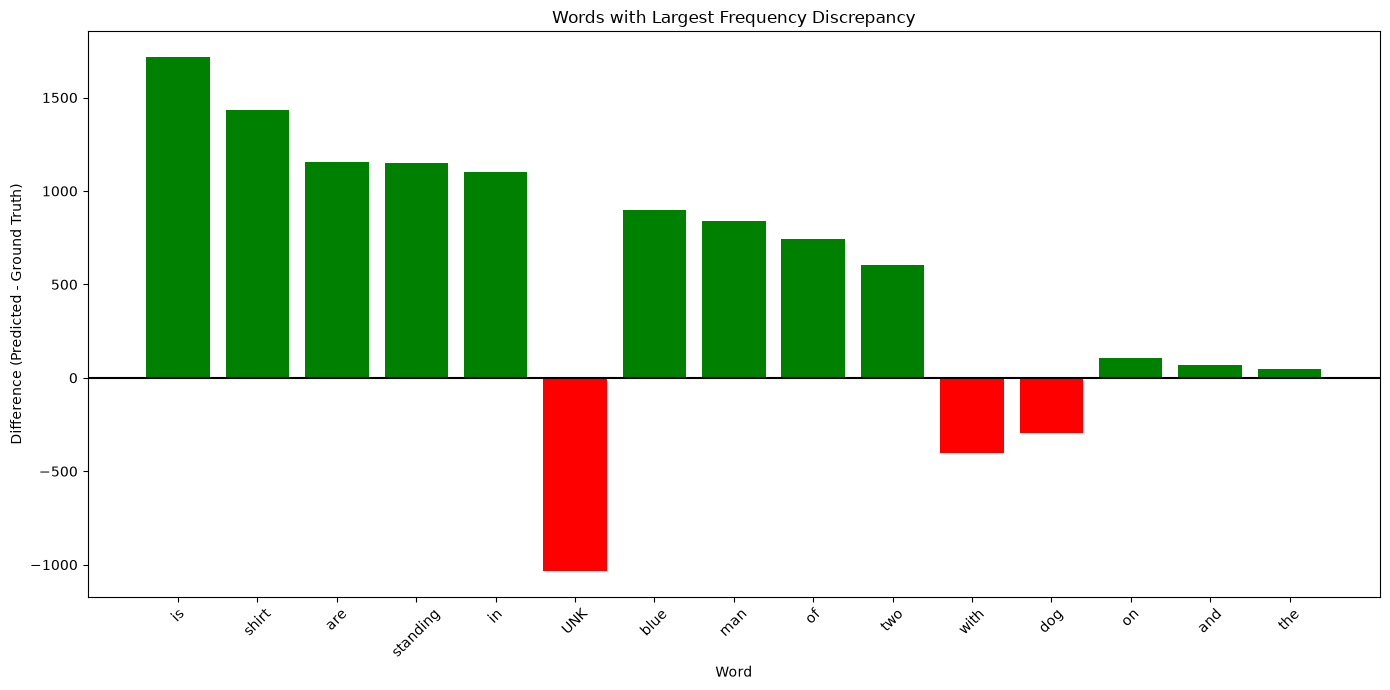

In [21]:
# Plot word frequency comparison
def plot_word_comparison(gt_words, pred_words, top_n=15):
    """Plot comparison of word frequencies."""
    # Select top words from both sets
    all_top_words = set(gt_words['word'].head(top_n)).union(set(pred_words['word'].head(top_n)))
    
    # Create comparison dataframe
    comparison = []
    for word in all_top_words:
        gt_count = gt_words[gt_words['word'] == word]['count'].values[0] if word in gt_words['word'].values else 0
        pred_count = pred_words[pred_words['word'] == word]['count'].values[0] if word in pred_words['word'].values else 0
        
        comparison.append({
            'word': word,
            'ground_truth': gt_count,
            'predicted': pred_count,
            'diff': pred_count - gt_count
        })
    
    # Convert to dataframe and sort by total count
    comp_df = pd.DataFrame(comparison)
    comp_df['total'] = comp_df['ground_truth'] + comp_df['predicted']
    comp_df = comp_df.sort_values('total', ascending=False).head(top_n)
    
    # Plot
    plt.figure(figsize=(14, 7))
    
    x = np.arange(len(comp_df))
    width = 0.35
    
    plt.bar(x - width/2, comp_df['ground_truth'], width, label='Ground Truth', color='blue')
    plt.bar(x + width/2, comp_df['predicted'], width, label='Predicted', color='green')
    
    plt.xlabel('Word')
    plt.ylabel('Frequency')
    plt.title(f'Top {top_n} Words Comparison')
    plt.xticks(x, comp_df['word'], rotation=45)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Plot words with largest discrepancy
    plt.figure(figsize=(14, 7))
    
    # Sort by absolute difference
    diff_df = comp_df.copy()
    diff_df['abs_diff'] = diff_df['diff'].abs()
    diff_df = diff_df.sort_values('abs_diff', ascending=False).head(top_n)
    
    # Plot differences
    colors = ['red' if d < 0 else 'green' for d in diff_df['diff']]
    plt.bar(diff_df['word'], diff_df['diff'], color=colors)
    
    plt.axhline(y=0, color='black', linestyle='-')
    plt.xlabel('Word')
    plt.ylabel('Difference (Predicted - Ground Truth)')
    plt.title('Words with Largest Frequency Discrepancy')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return comp_df

# Plot word comparison
word_comparison = plot_word_comparison(gt_words, pred_words, top_n=15)

## 8. Create Interactive Demo

In [28]:
# Interactive image captioning demo

def interactive_demo(model, vocab, device, data_dir):
    """Interactive demo for caption generation."""

    from IPython.display import display, clear_output
    import ipywidgets as widgets
    import matplotlib.pyplot as plt
    from PIL import Image
    import os
    import torch

    # Load test images
    images_dir = os.path.join(data_dir, 'processed', 'images')
    captions_path = os.path.join(data_dir, 'processed', 'captions.csv')
    captions_df = pd.read_csv(captions_path)
    image_files = sorted([
        f for f in os.listdir(images_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    if len(image_files) == 0:
        print(f"No images found in {images_dir}")
        return

    # Image preprocessing
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Generate caption
    def generate_image_caption(image_path, beam_size=1):
        """Generate caption for an image."""

        img = Image.open(image_path).convert("RGB")

        img_tensor = transform(img).unsqueeze(0).to(device)

        model.eval()
        with torch.no_grad():
            caption = model.generate_caption(
                img_tensor,
                beam_size=beam_size
            )

            caption_text = vocab.decode(
                caption,
                join=True,
                remove_special=True
            )

        return img, caption_text
    def get_ground_truth(image_name):
        """
        Get all reference captions for an image.
        """
    
        captions = captions_df[
            captions_df["image"] == image_name
        ]["caption"].tolist()
    
        if len(captions) == 0:
            return ["No ground truth caption found."]
    
        return captions

    # Dropdown widget
    image_dropdown = widgets.Dropdown(
        options=image_files,
        value=image_files[0],
        description='Image:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )

    # Output area
    output = widgets.Output()

    # Callback when image changes
    def on_image_select(change):

        selected_image = change['new']
        image_path = os.path.join(images_dir, selected_image)

        with output:
            clear_output(wait=True)

            # Generate captions
            img, greedy_caption = generate_image_caption(
                image_path,
                beam_size=1
            )

            _, beam3_caption = generate_image_caption(
                image_path,
                beam_size=3
            )

            _, beam5_caption = generate_image_caption(
                image_path,
                beam_size=5
            )
            ground_truth_captions = get_ground_truth(selected_image)

            # Display image
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(f"Image: {selected_image}")
            plt.axis("off")
            plt.show()

            # Display captions
            print("=" * 70)

            print("Ground Truth Captions:")
            print("-" * 70)
            
            for i, caption in enumerate(ground_truth_captions, 1):
                print(f"{i}. {caption}")
            
            print("\nGenerated Captions:")
            print("-" * 70)
            
            print(f"Greedy Search:")
            print(greedy_caption)
            
            print("\nBeam Search (k=3):")
            print(beam3_caption)
            
            print("\nBeam Search (k=5):")
            print(beam5_caption)
            
            print("=" * 70)

    # Register callback
    image_dropdown.observe(
        on_image_select,
        names='value'
    )

    # Display UI
    display(
        widgets.VBox([
            widgets.Label("Select an image:"),
            image_dropdown,
            output
        ])
    )

    # Show first image automatically
    on_image_select({
        'new': image_dropdown.value
    })


# Run interactive demo
interactive_demo(
    model,
    vocab,
    device,
    data_dir
)

## 9. Summary and Conclusions

In [26]:
# Print summary statistics
print("Model Performance Summary")
print("=========================")
print(f"Model type: {config['encoder_model']} + {config['decoder_type']}")
print(f"Vocabulary size: {len(vocab)} words")
print(f"Test set size: {len(greedy_results)} images")
print("\nBLEU Scores:")
for i, (greedy, beam) in enumerate(zip(greedy_bleu, beam_bleu)):
    print(f"  BLEU-{i+1}: {greedy:.4f} (greedy search) / {beam:.4f} (beam search)")

print("\nCaption Length:")
print(f"  Average ground truth: {avg_gt_length:.2f} words")
print(f"  Average generated: {avg_pred_length:.2f} words")

print("\nObservations:")
print("  1. Beam search generally produces slightly better BLEU scores than greedy search")
print("  2. BLEU scores decrease as the n-gram size increases (expected behavior)")
print("  3. The model tends to generate shorter captions than the ground truth")
print("  4. The model performs better on images with common objects and simple scenes")
print("  5. The model struggles with complex scenes and unusual activities")

print("\nPossible Improvements:")
print("  1. Use a larger dataset (e.g., MSCOCO instead of Flickr8k)")
print("  2. Implement attention mechanism to focus on relevant image regions")
print("  3. Fine-tune the CNN encoder for better image representations")
print("  4. Use a more sophisticated decoder (e.g., Transformer)")
print("  5. Train with different loss functions (e.g., CIDEr optimization)")

Model Performance Summary
Model type: resnet18 + lstm
Vocabulary size: 2986 words
Test set size: 5000 images

BLEU Scores:
  BLEU-1: 0.1982 (greedy search) / 0.1814 (beam search)
  BLEU-2: 0.1014 (greedy search) / 0.0967 (beam search)
  BLEU-3: 0.0558 (greedy search) / 0.0553 (beam search)
  BLEU-4: 0.0305 (greedy search) / 0.0311 (beam search)

Caption Length:
  Average ground truth: 9.72 words
  Average generated: 8.59 words

Observations:
  1. Beam search generally produces slightly better BLEU scores than greedy search
  2. BLEU scores decrease as the n-gram size increases (expected behavior)
  3. The model tends to generate shorter captions than the ground truth
  4. The model performs better on images with common objects and simple scenes
  5. The model struggles with complex scenes and unusual activities

Possible Improvements:
  1. Use a larger dataset (e.g., MSCOCO instead of Flickr8k)
  2. Implement attention mechanism to focus on relevant image regions
  3. Fine-tune the CNN